In [7]:
import glob
import os
import xarray as xa
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
from scipy.interpolate import RectBivariateSpline
from scipy.stats import pearsonr
from scipy.ndimage import convolve, rotate

import cartopy.crs as ccrs
from cartopy.feature import LAND, COASTLINE
import cmocean.cm as ocm

from subprocess import call
import shutil


In [3]:
#wget https://n5eil01u.ecs.nsidc.org/AMSA/AU_SI12.001/2016.01.01/AMSR_U2_L3_SeaIce12km_B04_20160101.he5
amsr2_dir = '/Volumes/sat_downloads/AMSR2/nsidc'

band_names = [
    'SI_12km_NH_18H_ASC',
    'SI_12km_NH_18V_ASC',
    'SI_12km_NH_23H_ASC',
    'SI_12km_NH_23V_ASC',
    'SI_12km_NH_36H_ASC',
    'SI_12km_NH_36V_ASC',
]

/var/folders/gs/j0b94wps7qb_qndm2zf0xdl40000gn/T/ipykernel_40044/3963006074.py:16: RuntimeWarning: invalid value encountered in cast
  bands_sca = np.clip(255 * (0.6 + (bands - bands_avg[None][None]) / bands_std[None][None] / 4), 0, 255).astype('uint8')


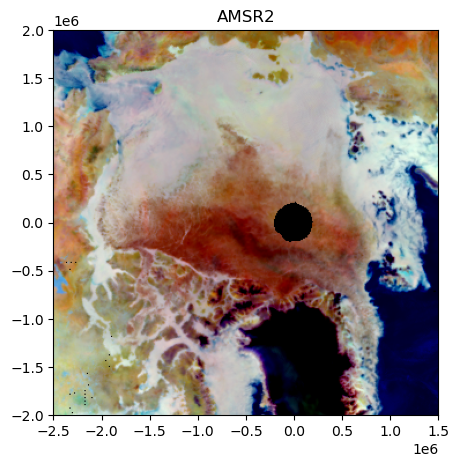

In [ ]:
for YEAR in range(2020, 2021):
    amsr2_file = f'{amsr2_dir}/AMSR_U2_L3_SeaIce12km_B04_{YEAR}0101.he5'
    with xa.open_dataset(amsr2_file, group='HDFEOS/GRIDS/NpPolarGrid12km/Data Fields') as ds:
        bands = np.dstack([ds[band_name].to_numpy() for band_name in band_names])
        amsr2_sic = ds['SI_12km_NH_ICECON_ASC'].to_numpy()

    with xa.open_dataset(amsr2_file, group='HDFEOS/GRIDS/NpPolarGrid12km') as ds:
        lon = ds.lon.to_numpy()
        lat = ds.lat.to_numpy()

    gpi = np.isfinite(bands[:,:,0]) * (amsr2_sic > 15) * (amsr2_sic <= 100)
    bands_gpi = bands[gpi, :]

    bands_avg = bands_gpi.mean(axis=0)
    bands_std = bands_gpi.std(axis=0)
    bands_sca = np.clip(255 * (0.6 + (bands - bands_avg[None][None]) / bands_std[None][None] / 4), 0, 255).astype('uint8')
    
    proj = ccrs.NorthPolarStereo(true_scale_latitude=60, central_longitude=-45)
    amsr_x, amsr_y, _ = proj.transform_points(ccrs.PlateCarree(), lon, lat).T
    amsr_x, amsr_y = amsr_x.T, amsr_y.T


    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(bands_sca[:,:,[0,3,5]])
    ax.set_title('AMSR2')
    ax.set_xlim([-2.5e6, 1.5e6])
    ax.set_ylim([-2e6, 2e6])
    ax.set_axis_off()
    plt.show()
    break


In [12]:
bands_sca_rot = rotate(bands_sca, -45, axes=(1, 0), reshape=False)

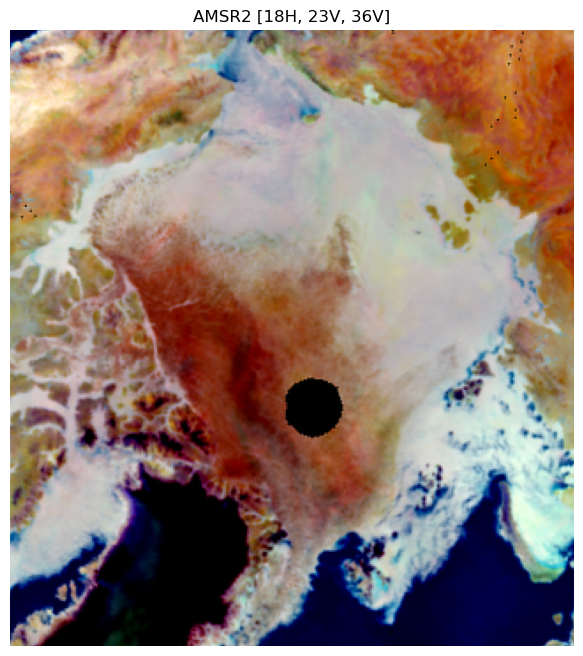

In [25]:
plt.figure(figsize=(8,8))
plt.imshow(bands_sca_rot[:,:,[0,3,5]])
plt.xlim([120, 440])
plt.ylim([600, 250])
plt.title('AMSR2 [18H, 23V, 36V]')
plt.gca().set_axis_off()

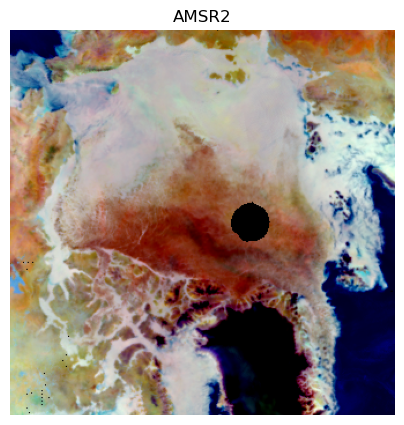

SyntaxError: 'break' outside loop (102076162.py, line 8)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(bands_sca[:,:,[0,3,5]], extent=[amsr_x.min(), amsr_x.max(), amsr_y.min(), amsr_y.max()])
ax.set_title('AMSR2')
ax.set_xlim([-2.5e6, 1.5e6])
ax.set_ylim([-2e6, 2e6])
ax.set_axis_off()
plt.show()
